### 1. Instalasi Library

Sel ini menjalankan perintah pip install untuk menginstal seluruh library Python yang dibutuhkan dalam proyek, mencakup pemrosesan data, machine learning, visualisasi, hingga pengembangan dashboard interaktif menggunakan Streamlit. Instalasi ini memastikan semua dependensi tersedia agar proses analisis dan pemodelan dapat berjalan dengan lancar tanpa error.

In [3]:
# ==============================================================================
# 1. INSTALL LIBRARY, judul Clustering Negara Berdasarkan Pola Deforestasi dan Reboisasi Global untuk Mendukung Kebijakan Lingkungan menggunakan Agglomerative
# ==============================================================================
!pip install -q scikit-learn pandas numpy matplotlib seaborn plotly openpyxl streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 94.0 MB/s eta 0:00:00


### 2. Import Library

Sel ini digunakan untuk mengimpor berbagai library Python yang mendukung seluruh proses dalam proyek, mulai dari pengolahan dan manipulasi data menggunakan pandas dan NumPy, visualisasi dengan matplotlib dan seaborn, hingga pengelolaan sistem seperti file dan proses dengan os, subprocess, dan pickle. Selain itu, digunakan juga library khusus seperti scikit-learn untuk preprocessing data, reduksi dimensi (PCA), penerapan algoritma clustering (K-Means, DBSCAN, dan Agglomerative), serta evaluasi model menggunakan metrik seperti silhouette score, Davies-Bouldin, dan Calinski-Harabasz. Library tambahan seperti pyngrok dan Streamlit digunakan untuk deployment dashboard, sementara pengaturan seperti penghilangan warning dan styling visualisasi dilakukan agar hasil output lebih rapi dan mudah dibaca.

In [4]:
# ==============================================================================
# 2. Import Library
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

from google.colab import files

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

warnings.filterwarnings('ignore')

### 3. Upload Dataset

Sel ini memungkinkan pengguna untuk mengunggah file dataset (CSV atau Excel) ke lingkungan Colab. Setelah file diunggah, data dibaca ke dalam DataFrame `df` dan beberapa baris pertama ditampilkan untuk preview.

In [5]:
# ==============================================================================
# 3. UPLOAD DATASET
# ==============================================================================
print("📂 Silakan upload file dataset (CSV / Excel) Anda:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

if filename.endswith('.csv'):
    df = pd.read_csv(filename, sep=None, engine='python')
elif filename.endswith('.xlsx') or filename.endswith('.xls'):
    df = pd.read_excel(filename)
else:
    raise ValueError("❌ Format file tidak didukung. Gunakan CSV atau Excel.")

print("\n✅ Dataset berhasil dimuat.")
print(f"📌 Nama file: {filename}")

print("\n📊 PREVIEW DATASET:")
display(df.head())


📂 Silakan upload file dataset (CSV / Excel) Anda:


Saving global 1.csv to global 1.csv

✅ Dataset berhasil dimuat.
📌 Nama file: global 1.csv

📊 PREVIEW DATASET:


,Country,Year,Forest_Area_km2,Land_Area_km2,Forest_Cover_Pct,Annual_Deforestation_Rate,Annual_Afforestation_Rate,Total_Carbon_Stock_Tonnes
0,Brazil,2000,5468301,8515767,6421,0,0,87197411954
1,Brazil,2001,5439758,8515767,6388,107,55,86742262748
2,Brazil,2002,5408757,8515767,6351,143,86,86247929409
3,Brazil,2003,5326870,8515767,6255,156,5,84942146407
4,Brazil,2004,5280984,8515767,6201,94,8,84210458080


### 4. EDA Awal Dataset

Bagian ini melakukan Exploratory Data Analysis (EDA) awal untuk memahami struktur data. Informasi yang ditampilkan meliputi dimensi data, tipe data setiap kolom, jumlah nilai yang hilang (missing values), dan statistik deskriptif dasar.

In [6]:
# ==============================================================================
# 4. EDA AWAL DATASET
# ==============================================================================
print("📊 EDA AWAL DATASET")
print("="*70)

print(f"✅ Dimensi Data Awal: {df.shape[0]} baris x {df.shape[1]} kolom")

print("\nℹ️ INFORMASI DATASET:")
df.info()

print("\n📌 Missing Values per Kolom:")
display(df.isnull().sum())

print("\n📈 Statistik Deskriptif:")
display(df.describe(include='all'))



📊 EDA AWAL DATASET
✅ Dimensi Data Awal: 5720 baris x 8 kolom

ℹ️ INFORMASI DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5720 entries, 0 to 5719
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Country                    5720 non-null   object
 1   Year                       5720 non-null   int64 
 2   Forest_Area_km2            5720 non-null   int64 
 3   Land_Area_km2              5720 non-null   int64 
 4   Forest_Cover_Pct           5720 non-null   int64 
 5   Annual_Deforestation_Rate  5720 non-null   int64 
 6   Annual_Afforestation_Rate  5720 non-null   int64 
 7   Total_Carbon_Stock_Tonnes  5720 non-null   object
dtypes: int64(6), object(2)
memory usage: 357.6+ KB

📌 Missing Values per Kolom:


,0
Country,0
Year,0
Forest_Area_km2,0
Land_Area_km2,0
Forest_Cover_Pct,0
Annual_Deforestation_Rate,0
Annual_Afforestation_Rate,0
Total_Carbon_Stock_Tonnes,0



📈 Statistik Deskriptif:


,Country,Year,Forest_Area_km2,Land_Area_km2,Forest_Cover_Pct,Annual_Deforestation_Rate,Annual_Afforestation_Rate,Total_Carbon_Stock_Tonnes
count,5720,5720.000000,5.720000e+03,5.720000e+03,5720.000000,5720.000000,5720.00000,5720
unique,220,NaN,NaN,NaN,NaN,NaN,NaN,5718
top,Brazil,NaN,NaN,NaN,NaN,NaN,NaN,29949
freq,26,NaN,NaN,NaN,NaN,NaN,NaN,2
mean,NaN,2012.500000,2.488515e+05,6.130764e+05,3454.666958,58.559790,48.45472,NaN
std,NaN,7.500656,8.085413e+05,1.811260e+06,1714.779249,52.140011,32.69251,NaN
min,NaN,2000.000000,0.000000e+00,0.000000e+00,9.000000,0.000000,0.00000,NaN
25%,NaN,2006.000000,6.947500e+03,2.129450e+04,2282.000000,13.000000,18.00000,NaN
50%,NaN,2012.500000,3.247850e+04,9.276700e+04,3741.500000,43.000000,48.00000,NaN
75%,NaN,2019.000000,1.581042e+05,4.481238e+05,4713.000000,101.000000,76.00000,NaN


### 5. Data Cleaning dan Konversi Tipe Data

Sel ini membersihkan data dengan mengonversi kolom-kolom numerik ke tipe data yang sesuai, menangani nilai yang tidak valid (coerce errors), menghapus baris dengan nilai 'Country' yang kosong, dan mengisi missing values dengan median. Data juga diurutkan berdasarkan negara dan tahun.

In [7]:
# ==============================================================================
# 5. DATA CLEANING DAN KONVERSI TIPE DATA
# ==============================================================================
print("🧹 MEMBERSIHKAN DATA...")
print("="*70)

numeric_cols = [
    'Year',
    'Forest_Area_km2',
    'Land_Area_km2',
    'Forest_Cover_Pct',
    'Annual_Deforestation_Rate',
    'Annual_Afforestation_Rate',
    'Total_Carbon_Stock_Tonnes'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['Country']).copy()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df = df.sort_values(by=['Country', 'Year']).reset_index(drop=True)

print("✅ Data cleaning selesai.")
display(df.head())



🧹 MEMBERSIHKAN DATA...
✅ Data cleaning selesai.


,Country,Year,Forest_Area_km2,Land_Area_km2,Forest_Cover_Pct,Annual_Deforestation_Rate,Annual_Afforestation_Rate,Total_Carbon_Stock_Tonnes
0,Afghanistan,2000,210339,652230,3225,0,0,1.170723e+09
1,Afghanistan,2001,210951,652230,3234,3,32,1.174132e+09
2,Afghanistan,2002,211759,652230,3247,29,68,1.178627e+09
3,Afghanistan,2003,212421,652230,3257,38,69,1.182313e+09
4,Afghanistan,2004,212807,652230,3263,2,38,1.184459e+09


### 6. Cek dan Perbaiki Skala Persentase

Sel ini memeriksa kolom `Forest_Cover_Pct` untuk memastikan bahwa nilai-nilainya berada dalam skala persentase (0-100). Jika ditemukan nilai yang mengindikasikan skala x100, maka akan dinormalisasi ke skala persentase yang benar.

In [8]:
# ==============================================================================
# 6. CEK DAN PERBAIKI SKALA PERSENTASE
# ==============================================================================
print("📏 CEK SKALA PERSENTASE")
print("="*70)

if df['Forest_Cover_Pct'].max() > 100:
    df['Forest_Cover_Pct'] = df['Forest_Cover_Pct'] / 100
    print("✅ Forest_Cover_Pct dikonversi dari skala x100 ke persen normal.")
else:
    print("✅ Forest_Cover_Pct sudah dalam skala persen normal.")

display(df[['Forest_Cover_Pct']].describe())


📏 CEK SKALA PERSENTASE
✅ Forest_Cover_Pct dikonversi dari skala x100 ke persen normal.


,Forest_Cover_Pct
count,5720.000000
mean,34.546670
std,17.147792
min,0.090000
25%,22.820000
50%,37.415000
75%,47.130000
max,79.970000


### 7. Agregasi Data Menjadi Level Negara

Sel ini mengagregasi data tahunan ke level negara. Untuk setiap negara, dihitung rata-rata, nilai awal, dan nilai akhir dari berbagai fitur. Fitur-fitur baru seperti perubahan luas hutan dan stok karbon juga dihitung untuk menangkap dinamika perubahan dari waktu ke waktu.

In [9]:
# ==============================================================================
# 7. AGREGASI DATA MENJADI LEVEL NEGARA
# ==============================================================================
print("🌍 AGREGASI DATA MENJADI LEVEL NEGARA")
print("="*70)

df['Net_Forest_Change'] = df['Annual_Afforestation_Rate'] - df['Annual_Deforestation_Rate']

df_country = df.groupby('Country').agg({
    'Forest_Area_km2': ['mean', 'first', 'last'],
    'Forest_Cover_Pct': ['mean', 'first', 'last'],
    'Annual_Deforestation_Rate': 'mean',
    'Annual_Afforestation_Rate': 'mean',
    'Net_Forest_Change': 'mean',
    'Total_Carbon_Stock_Tonnes': ['mean', 'first', 'last'],
    'Land_Area_km2': 'mean'
}).reset_index()

df_country.columns = [
    'Country',
    'Forest_Area_Mean', 'Forest_Area_First', 'Forest_Area_Last',
    'Forest_Cover_Mean', 'Forest_Cover_First', 'Forest_Cover_Last',
    'Deforestation_Mean',
    'Afforestation_Mean',
    'Net_Forest_Change_Mean',
    'Carbon_Stock_Mean', 'Carbon_Stock_First', 'Carbon_Stock_Last',
    'Land_Area_Mean'
]

df_country['Forest_Area_Change'] = df_country['Forest_Area_Last'] - df_country['Forest_Area_First']
df_country['Forest_Cover_Change'] = df_country['Forest_Cover_Last'] - df_country['Forest_Cover_First']
df_country['Carbon_Stock_Change'] = df_country['Carbon_Stock_Last'] - df_country['Carbon_Stock_First']

print("✅ Data berhasil diagregasi menjadi level negara.")
print(f"📌 Jumlah negara: {df_country.shape[0]}")
display(df_country.head())



🌍 AGREGASI DATA MENJADI LEVEL NEGARA
✅ Data berhasil diagregasi menjadi level negara.
📌 Jumlah negara: 220


,Country,Forest_Area_Mean,Forest_Area_First,Forest_Area_Last,Forest_Cover_Mean,Forest_Cover_First,Forest_Cover_Last,Deforestation_Mean,Afforestation_Mean,Net_Forest_Change_Mean,Carbon_Stock_Mean,Carbon_Stock_First,Carbon_Stock_Last,Land_Area_Mean,Forest_Area_Change,Forest_Cover_Change,Carbon_Stock_Change
0,Afghanistan,214828.846154,210339,211690,31.798846,32.25,32.46,44.269231,50.269231,6.000000,1.195714e+09,1.170723e+09,1.178245e+09,652230.0,1351,0.21,7522249.0
1,Albania,12999.423077,12227,13898,45.220385,42.53,48.35,20.230769,68.384615,48.153846,9.464905e+07,8.902501e+07,1.011924e+08,28748.0,1671,5.82,12167431.0
2,Algeria,555104.461538,585743,537783,20.914615,24.59,22.58,65.961538,49.192308,-16.769231,8.649186e+09,9.126570e+09,8.379299e+09,2381741.0,-47960,-2.01,-747271661.0
3,Andorra,200.538462,189,216,39.899231,40.57,46.28,18.076923,66.269231,48.192308,1.444800e+06,1.364348e+06,1.556276e+06,468.0,27,5.71,191928.0
4,Angola,696737.461538,706270,689003,50.055385,56.65,55.27,51.384615,50.730769,-0.653846,1.075942e+10,1.090663e+10,1.063999e+10,1246700.0,-17267,-1.38,-266639061.0


### 8. Feature Engineering Khusus Pola Deforestasi & Reboisasi

Sel ini membuat fitur-fitur baru (engineered features) yang lebih kompleks untuk menangkap pola deforestasi dan reboisasi. Fitur-fitur ini mencakup rasio, intensitas, dan indeks perubahan hutan, yang akan menjadi input utama untuk clustering.

In [10]:
# ==============================================================================
# 8. FEATURE ENGINEERING KHUSUS POLA DEFORESTASI & REBOISASI
# ==============================================================================
print("⚙️ FEATURE ENGINEERING")
print("="*70)

eps = 1e-9

df_country['Forest_Area_to_Land_Ratio'] = df_country['Forest_Area_Mean'] / (df_country['Land_Area_Mean'] + eps)
df_country['Carbon_per_Forest_Area'] = df_country['Carbon_Stock_Mean'] / (df_country['Forest_Area_Mean'] + eps)

df_country['Deforestation_Intensity'] = df_country['Deforestation_Mean'] / (df_country['Forest_Area_Mean'] + eps)
df_country['Afforestation_Intensity'] = df_country['Afforestation_Mean'] / (df_country['Forest_Area_Mean'] + eps)

df_country['Forest_Area_Change_Ratio'] = df_country['Forest_Area_Change'] / (df_country['Forest_Area_First'] + eps)
df_country['Forest_Cover_Change_Ratio'] = df_country['Forest_Cover_Change'] / (df_country['Forest_Cover_First'] + eps)
df_country['Carbon_Stock_Change_Ratio'] = df_country['Carbon_Stock_Change'] / (df_country['Carbon_Stock_First'] + eps)

df_country['Reforestation_Effectiveness'] = df_country['Afforestation_Mean'] / (df_country['Deforestation_Mean'] + eps)
df_country['Forest_Pressure_Index'] = df_country['Deforestation_Mean'] - df_country['Afforestation_Mean']
df_country['Forest_Stability_Index'] = abs(df_country['Forest_Cover_Change'])

print("✅ Feature engineering selesai.")
display(df_country.head())



⚙️ FEATURE ENGINEERING
✅ Feature engineering selesai.


,Country,Forest_Area_Mean,Forest_Area_First,Forest_Area_Last,Forest_Cover_Mean,Forest_Cover_First,Forest_Cover_Last,Deforestation_Mean,Afforestation_Mean,Net_Forest_Change_Mean,...,Forest_Area_to_Land_Ratio,Carbon_per_Forest_Area,Deforestation_Intensity,Afforestation_Intensity,Forest_Area_Change_Ratio,Forest_Cover_Change_Ratio,Carbon_Stock_Change_Ratio,Reforestation_Effectiveness,Forest_Pressure_Index,Forest_Stability_Index
0,Afghanistan,214828.846154,210339,211690,31.798846,32.25,32.46,44.269231,50.269231,6.000000,...,0.329376,5565.892266,0.000206,0.000234,0.006423,0.006512,0.006425,1.135534,-6.000000,0.21
1,Albania,12999.423077,12227,13898,45.220385,42.53,48.35,20.230769,68.384615,48.153846,...,0.452185,7281.019445,0.001556,0.005261,0.136665,0.136845,0.136674,3.380228,-48.153846,5.82
2,Algeria,555104.461538,585743,537783,20.914615,24.59,22.58,65.961538,49.192308,-16.769231,...,0.233067,15581.186730,0.000119,0.000089,-0.081879,-0.081741,-0.081879,0.745773,16.769231,2.01
3,Andorra,200.538462,189,216,39.899231,40.57,46.28,18.076923,66.269231,48.192308,...,0.428501,7204.601266,0.090142,0.330456,0.142857,0.140744,0.140674,3.665957,-48.192308,5.71
4,Angola,696737.461538,706270,689003,50.055385,56.65,55.27,51.384615,50.730769,-0.653846,...,0.558865,15442.580437,0.000074,0.000073,-0.024448,-0.024360,-0.024447,0.987275,0.653846,1.38


### 9. Pemilihan Fitur Clustering

Sel ini menentukan subset fitur dari hasil feature engineering yang akan digunakan untuk proses clustering. Daftar fitur yang dipilih ditampilkan untuk referensi.

In [11]:
# ==============================================================================
# 9. PEMILIHAN FITUR CLUSTERING
# ==============================================================================
print("📌 PEMILIHAN FITUR CLUSTERING")
print("="*70)

FEATURES = [
    'Forest_Cover_Mean',
    'Net_Forest_Change_Mean',
    'Forest_Area_to_Land_Ratio',
    'Carbon_per_Forest_Area',
    'Deforestation_Intensity',
    'Afforestation_Intensity',
    'Forest_Area_Change_Ratio',
    'Forest_Cover_Change_Ratio',
    'Carbon_Stock_Change_Ratio',
    'Reforestation_Effectiveness',
    'Forest_Pressure_Index',
    'Forest_Stability_Index'
]

df_num = df_country[FEATURES].copy()

print("Fitur yang digunakan:")
for i, col in enumerate(FEATURES, 1):
    print(f"{i}. {col}")

display(df_num.head())


📌 PEMILIHAN FITUR CLUSTERING
Fitur yang digunakan:
1. Forest_Cover_Mean
2. Net_Forest_Change_Mean
3. Forest_Area_to_Land_Ratio
4. Carbon_per_Forest_Area
5. Deforestation_Intensity
6. Afforestation_Intensity
7. Forest_Area_Change_Ratio
8. Forest_Cover_Change_Ratio
9. Carbon_Stock_Change_Ratio
10. Reforestation_Effectiveness
11. Forest_Pressure_Index
12. Forest_Stability_Index


,Forest_Cover_Mean,Net_Forest_Change_Mean,Forest_Area_to_Land_Ratio,Carbon_per_Forest_Area,Deforestation_Intensity,Afforestation_Intensity,Forest_Area_Change_Ratio,Forest_Cover_Change_Ratio,Carbon_Stock_Change_Ratio,Reforestation_Effectiveness,Forest_Pressure_Index,Forest_Stability_Index
0,31.798846,6.000000,0.329376,5565.892266,0.000206,0.000234,0.006423,0.006512,0.006425,1.135534,-6.000000,0.21
1,45.220385,48.153846,0.452185,7281.019445,0.001556,0.005261,0.136665,0.136845,0.136674,3.380228,-48.153846,5.82
2,20.914615,-16.769231,0.233067,15581.186730,0.000119,0.000089,-0.081879,-0.081741,-0.081879,0.745773,16.769231,2.01
3,39.899231,48.192308,0.428501,7204.601266,0.090142,0.330456,0.142857,0.140744,0.140674,3.665957,-48.192308,5.71
4,50.055385,-0.653846,0.558865,15442.580437,0.000074,0.000073,-0.024448,-0.024360,-0.024447,0.987275,0.653846,1.38


### 10. Visualisasi Korelasi Fitur

Sel ini menghasilkan heatmap untuk memvisualisasikan korelasi antara fitur-fitur yang dipilih. Ini membantu dalam memahami hubungan antar fitur dan mengidentifikasi potensi redundansi.

📊 HEATMAP KORELASI FITUR


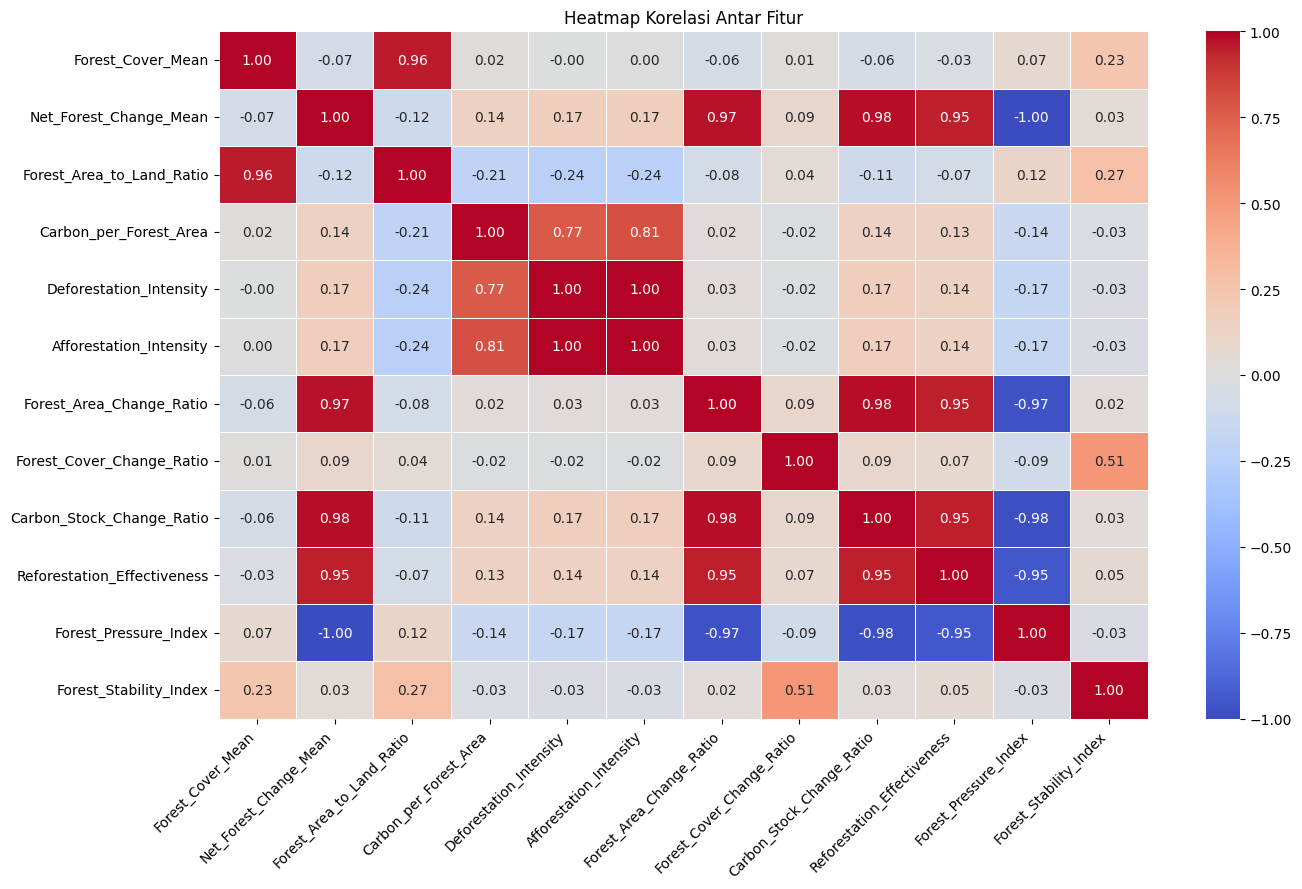

In [12]:
# ==============================================================================
# 10. VISUALISASI KORELASI FITUR
# ==============================================================================
print("📊 HEATMAP KORELASI FITUR")
print("="*70)

corr = df_num.corr()

plt.figure(figsize=(14, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Heatmap Korelasi Antar Fitur")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 11. Preprocessing Data

Sel ini melakukan langkah-langkah preprocessing data meliputi imputasi missing values, clipping outlier ringan, dan scaling menggunakan `RobustScaler`. Tujuannya adalah untuk mempersiapkan data agar optimal untuk algoritma clustering. Imputasi adalah proses mengisi nilai yang hilang (missing values) pada dataset dengan nilai pengganti tertentu. Clipping (sering disebut juga Winsorizing) adalah teknik untuk menangani pencilan (outliers) dengan cara membatasi nilai data pada ambang batas tertentu. Scaling adalah proses menyamakan skala antar fitur (variabel) agar memiliki rentang nilai yang sebanding. Dalam clustering yang berbasis jarak, fitur dengan angka besar (misalnya: Luas Wilayah) akan mendominasi fitur dengan angka kecil (misalnya: Laju Pertumbuhan) jika tidak discaling.

RobustScaler adalah jenis penskalaan yang sangat efektif jika data masih mengandung outlier.

Mekanisme: Penskalaan ini menggunakan statistik yang tidak terpengaruh oleh pencilan, yaitu Median dan Interquartile Range (IQR).

In [13]:
# ==============================================================================
# 11. PREPROCESSING DATA
# ==============================================================================
print("⚙️ PREPROCESSING DATA")
print("="*70)

# ------------------------------------------------------------------------------
# Gunakan fitur utama yang lebih relevan dan tidak terlalu redundan
# ------------------------------------------------------------------------------
SELECTED_FEATURES = [
    'Forest_Cover_Mean',
    'Net_Forest_Change_Mean',
    'Forest_Area_to_Land_Ratio',
    'Carbon_per_Forest_Area',
    'Deforestation_Intensity',
    'Afforestation_Intensity',
    'Forest_Area_Change_Ratio',
    'Forest_Cover_Change_Ratio',
    'Reforestation_Effectiveness',
    'Forest_Pressure_Index',
    'Forest_Stability_Index'
]

X_selected_df = df_country[SELECTED_FEATURES].copy()

print("📌 Fitur utama yang dipakai untuk eksperimen clustering:")
for i, col in enumerate(SELECTED_FEATURES, 1):
    print(f"{i}. {col}")

# ------------------------------------------------------------------------------
# Imputasi missing values
# ------------------------------------------------------------------------------
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X_selected_df)

# ------------------------------------------------------------------------------
# Clip outlier ringan (lebih realistis daripada terlalu keras)
# ------------------------------------------------------------------------------
lower = np.percentile(X_imp, 2, axis=0)
upper = np.percentile(X_imp, 98, axis=0)
X_clip = np.clip(X_imp, lower, upper)

# ------------------------------------------------------------------------------
# Scaling robust
# ------------------------------------------------------------------------------
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_clip)

# Balik ke dataframe supaya nama kolom tetap aman
X_selected_df = pd.DataFrame(X_scaled, columns=SELECTED_FEATURES)

print("✅ Preprocessing selesai.")
print("Shape data clustering:", X_selected_df.shape)
display(X_selected_df.head())

⚙️ PREPROCESSING DATA
📌 Fitur utama yang dipakai untuk eksperimen clustering:
1. Forest_Cover_Mean
2. Net_Forest_Change_Mean
3. Forest_Area_to_Land_Ratio
4. Carbon_per_Forest_Area
5. Deforestation_Intensity
6. Afforestation_Intensity
7. Forest_Area_Change_Ratio
8. Forest_Cover_Change_Ratio
9. Reforestation_Effectiveness
10. Forest_Pressure_Index
11. Forest_Stability_Index
✅ Preprocessing selesai.
Shape data clustering: (220, 11)


,Forest_Cover_Mean,Net_Forest_Change_Mean,Forest_Area_to_Land_Ratio,Carbon_per_Forest_Area,Deforestation_Intensity,Afforestation_Intensity,Forest_Area_Change_Ratio,Forest_Cover_Change_Ratio,Reforestation_Effectiveness,Forest_Pressure_Index,Forest_Stability_Index
0,-0.205968,1.017989,-0.340622,-0.857678,-0.114804,-0.197103,0.969946,0.315091,1.278998,-1.017989,-0.846529
1,0.482092,2.564374,0.245823,-0.647004,0.016571,0.631534,2.876906,0.933385,7.565589,-2.564374,0.520097
2,-0.763953,0.182716,-0.800522,0.372525,-0.123292,-0.221068,-0.322943,-0.103574,0.187414,-0.182716,-0.408039
3,0.209301,2.565785,0.132725,-0.656391,8.635856,54.240241,2.967572,0.951886,8.365815,-2.565785,0.493301
4,0.729960,0.773898,0.755247,0.355500,-0.127678,-0.223674,0.517940,0.168636,0.863778,-0.773898,-0.561510


### 12. Analisis PCA (Hanya untuk Eksplorasi)

Sel ini melakukan analisis Principal Component Analysis (PCA) sebagai alat eksplorasi untuk mengurangi dimensi dan memahami variansi data. Scree plot ditampilkan untuk membantu dalam pemilihan jumlah komponen PCA.

Tujuan Utama: Menentukan jumlah komponen optimal untuk menyederhanakan data (Reduksi Dimensi) tanpa kehilangan banyak informasi.

Informasi di Sumbu Y: Menunjukkan persentase informasi (varians) yang berhasil ditangkap. Angka 1.00 berarti 100% informasi data asli.

Dominasi Komponen Pertama: Komponen 1 sangat dominan karena mampu merangkum sekitar 91,5% varians data sendirian.

Titik Siku (Elbow): Terjadi di antara komponen 2 dan 3. Setelah titik ini, garis mulai mendatar, artinya penambahan komponen berikutnya tidak lagi memberikan tambahan informasi yang berarti.

🧠 PCA - ANALISIS EKSPLORASI


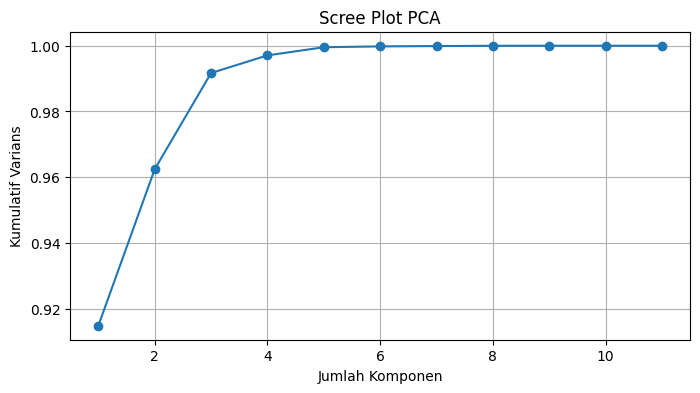

✅ Analisis PCA selesai.
📌 PCA hanya digunakan sebagai salah satu representasi kandidat, bukan dipaksa untuk semua model.


In [14]:
# ==============================================================================
# 12. ANALISIS PCA (HANYA UNTUK EKSPLORASI, BUKAN LANGSUNG MODEL FINAL)
# ==============================================================================
print("🧠 PCA - ANALISIS EKSPLORASI")
print("="*70)

pca_full = PCA().fit(X_selected_df)

plt.figure(figsize=(8,4))
plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    np.cumsum(pca_full.explained_variance_ratio_),
    marker='o'
)
plt.title("Scree Plot PCA")
plt.xlabel("Jumlah Komponen")
plt.ylabel("Kumulatif Varians")
plt.grid(True)
plt.show()

X_pca2_preview = PCA(n_components=2, random_state=42).fit_transform(X_selected_df)

print("✅ Analisis PCA selesai.")
print("📌 PCA hanya digunakan sebagai salah satu representasi kandidat, bukan dipaksa untuk semua model.")

### 13. Perbandingan 3 Algoritma Clustering (Super Tuning)

Sel ini adalah bagian inti dari eksperimen clustering. Dilakukan tuning parameter yang ekstensif untuk tiga algoritma (K-Means, Agglomerative, DBSCAN) pada berbagai subset fitur dan representasi data (dengan/tanpa PCA). Setiap kombinasi dievaluasi menggunakan metrik Silhouette, Davies-Bouldin, dan Calinski-Harabasz.

In [15]:
# ==============================================================================
# 13. PERBANDINGAN 3 ALGORITMA CLUSTERING (SUPER TUNING)
# ==============================================================================
print("🔍 PERBANDINGAN 3 ALGORITMA CLUSTERING - SUPER TUNING")
print("="*70)

from itertools import combinations

results = []

# ------------------------------------------------------------------------------
# FUNGSI EVALUASI CLUSTER
# ------------------------------------------------------------------------------
def evaluate_clustering(X, labels, algo_name, param_text, rep_name, feature_set_name):
    unique_labels = set(labels)
    valid_clusters = unique_labels - {-1}

    # Minimal 3 cluster valid
    if len(valid_clusters) < 3:
        return

    # Hindari semua data masuk satu cluster
    if len(set(labels)) <= 1:
        return

    # Cek distribusi cluster
    label_series = pd.Series(labels)
    cluster_counts = label_series[label_series != -1].value_counts()

    if len(cluster_counts) < 3:
        return

    # Minimal tiap cluster berisi 2 negara
    if cluster_counts.min() < 2:
        return

    try:
        sil = silhouette_score(X, labels)
        dbi = davies_bouldin_score(X, labels)
        ch = calinski_harabasz_score(X, labels)

        results.append({
            'Feature_Set': feature_set_name,
            'Representasi': rep_name,
            'Algoritma': algo_name,
            'Parameter': param_text,
            'Jumlah_Cluster': len(valid_clusters),
            'Silhouette': sil,
            'Kualitas_Cluster_(%)': sil * 100,
            'Davies_Bouldin': dbi,
            'Calinski_Harabasz': ch
        })
    except:
        pass

# ------------------------------------------------------------------------------
# STRATEGI: COBA BANYAK SUBSET FITUR
# ------------------------------------------------------------------------------
candidate_features = SELECTED_FEATURES.copy()
feature_subsets = []

# Full feature set
feature_subsets.append(candidate_features)

# Kombinasi subset fitur (minimal 4 fitur)
for r in range(4, len(candidate_features) + 1):
    for comb in combinations(candidate_features, r):
        feature_subsets.append(list(comb))

# Batasi supaya Colab tidak terlalu berat
feature_subsets = feature_subsets[:120]

print(f"📌 Jumlah subset fitur yang diuji: {len(feature_subsets)}")

for idx, feat_subset in enumerate(feature_subsets, 1):
    print(f"🔎 Menguji subset fitur {idx}/{len(feature_subsets)}")

    X_base = X_selected_df[feat_subset].values

    # --------------------------------------------------------------------------
    # Buat beberapa representasi data
    # --------------------------------------------------------------------------
    subset_representations = {}
    subset_representations['No_PCA'] = X_base

    try:
        subset_representations['PCA_95'] = PCA(n_components=0.95, random_state=42).fit_transform(X_base)
    except:
        pass

    max_comp = min(X_base.shape[1], 8)
    for n in range(2, max_comp + 1):
        try:
            subset_representations[f'PCA_{n}'] = PCA(n_components=n, random_state=42).fit_transform(X_base)
        except:
            pass

    # --------------------------------------------------------------------------
    # LOOP SEMUA REPRESENTASI
    # --------------------------------------------------------------------------
    for rep_name, X_test in subset_representations.items():

        # ==================================================
        # 1) K-MEANS
        # ==================================================
        for k in range(3, 9):
            try:
                model = KMeans(
                    n_clusters=k,
                    random_state=42,
                    n_init=100,
                    max_iter=2000
                )
                labels = model.fit_predict(X_test)
                evaluate_clustering(X_test, labels, 'K-Means', f'k={k}', rep_name, str(feat_subset))
            except:
                pass

        # ==================================================
        # 2) AGGLOMERATIVE
        # ==================================================
        for k in range(3, 9):
            for linkage in ['ward', 'complete', 'average', 'single']:
                try:
                    if linkage == 'ward':
                        model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
                    else:
                        model = AgglomerativeClustering(
                            n_clusters=k,
                            linkage=linkage,
                            metric='euclidean'
                        )

                    labels = model.fit_predict(X_test)
                    evaluate_clustering(X_test, labels, 'Agglomerative', f'k={k}, linkage={linkage}', rep_name, str(feat_subset))
                except:
                    pass

        # ==================================================
        # 3) DBSCAN
        # ==================================================
        for eps_val in np.arange(0.10, 1.51, 0.03):
            for ms in range(3, 9):
                try:
                    model = DBSCAN(eps=float(eps_val), min_samples=ms)
                    labels = model.fit_predict(X_test)
                    evaluate_clustering(X_test, labels, 'DBSCAN', f'eps={eps_val:.2f}, min_samples={ms}', rep_name, str(feat_subset))
                except:
                    pass

# ------------------------------------------------------------------------------
# HASIL EVALUASI
# ------------------------------------------------------------------------------
df_eval = pd.DataFrame(results)

if df_eval.empty:
    raise ValueError("❌ Tidak ada hasil clustering valid dengan minimal 3 cluster.")

# Ranking global
df_eval = df_eval.sort_values(
    by=['Silhouette', 'Davies_Bouldin', 'Calinski_Harabasz'],
    ascending=[False, True, False]
).reset_index(drop=True)

print("🏆 HASIL PERBANDINGAN 3 ALGORITMA (SEMUA HASIL):")
display(df_eval.head(50))

TARGET_MIN = 0.95
TARGET_MAX = 0.97

df_eval_target = df_eval[
    (df_eval['Silhouette'] >= TARGET_MIN) &
    (df_eval['Silhouette'] <= TARGET_MAX) &
    (df_eval['Jumlah_Cluster'] >= 3)
].copy()

print("\n🎯 HASIL DALAM RENTANG TARGET 95% - 97%:")
if not df_eval_target.empty:
    display(df_eval_target.head(30))
else:
    print("⚠️ Tidak ada hasil dalam rentang 95% - 97%. Nanti sistem akan ambil hasil terbaik yang paling mendekati.")

print("\n📌 Statistik Ringkas Silhouette:")
print(df_eval['Silhouette'].describe())

print("\n📌 Distribusi jumlah hasil per algoritma:")
display(df_eval['Algoritma'].value_counts())

# Hasil terlalu tinggi (>0.98) tetap disimpan, tapi tidak diprioritaskan
df_eval_realistic = df_eval[df_eval['Silhouette'] <= 0.98].copy()

if not df_eval_realistic.empty:
    print("\n✅ Dibuat versi hasil yang lebih realistis (Silhouette <= 0.98)")
    display(df_eval_realistic.head(30))
else:
    print("\n⚠️ Semua hasil di atas 0.98, sistem tetap akan memakai hasil penuh.")
    df_eval_realistic = df_eval.copy()


🔍 PERBANDINGAN 3 ALGORITMA CLUSTERING - SUPER TUNING
📌 Jumlah subset fitur yang diuji: 120
🔎 Menguji subset fitur 1/120
🔎 Menguji subset fitur 2/120
🔎 Menguji subset fitur 3/120
🔎 Menguji subset fitur 4/120
🔎 Menguji subset fitur 5/120
🔎 Menguji subset fitur 6/120
🔎 Menguji subset fitur 7/120
🔎 Menguji subset fitur 8/120
🔎 Menguji subset fitur 9/120
🔎 Menguji subset fitur 10/120
🔎 Menguji subset fitur 11/120
🔎 Menguji subset fitur 12/120
🔎 Menguji subset fitur 13/120
🔎 Menguji subset fitur 14/120
🔎 Menguji subset fitur 15/120
🔎 Menguji subset fitur 16/120
🔎 Menguji subset fitur 17/120
🔎 Menguji subset fitur 18/120
🔎 Menguji subset fitur 19/120
🔎 Menguji subset fitur 20/120
🔎 Menguji subset fitur 21/120
🔎 Menguji subset fitur 22/120
🔎 Menguji subset fitur 23/120
🔎 Menguji subset fitur 24/120
🔎 Menguji subset fitur 25/120
🔎 Menguji subset fitur 26/120
🔎 Menguji subset fitur 27/120
🔎 Menguji subset fitur 28/120
🔎 Menguji subset fitur 29/120
🔎 Menguji subset fitur 30/120
🔎 Menguji subset f

,Feature_Set,Representasi,Algoritma,Parameter,Jumlah_Cluster,Silhouette,Kualitas_Cluster_(%),Davies_Bouldin,Calinski_Harabasz
0,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=complete",3,0.954284,95.428372,0.142696,8494.001754
1,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=average",3,0.954284,95.428372,0.142696,8494.001754
2,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=single",3,0.954284,95.428372,0.142696,8494.001754
3,"['Forest_Cover_Mean', 'Net_Forest_Change_Mean'...",PCA_95,Agglomerative,"k=3, linkage=complete",3,0.954139,95.413936,0.142510,8463.781630
4,"['Forest_Cover_Mean', 'Net_Forest_Change_Mean'...",PCA_95,Agglomerative,"k=3, linkage=average",3,0.954139,95.413936,0.142510,8463.781630
5,"['Forest_Cover_Mean', 'Net_Forest_Change_Mean'...",PCA_95,Agglomerative,"k=3, linkage=single",3,0.954139,95.413936,0.142510,8463.781630
6,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=complete",3,0.954139,95.413936,0.142510,8463.781630
7,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=average",3,0.954139,95.413936,0.142510,8463.781630
8,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=single",3,0.954139,95.413936,0.142510,8463.781630
9,"['Forest_Cover_Mean', 'Carbon_per_Forest_Area'...",PCA_95,Agglomerative,"k=3, linkage=complete",3,0.954125,95.412520,0.142498,8461.414949



🎯 HASIL DALAM RENTANG TARGET 95% - 97%:


,Feature_Set,Representasi,Algoritma,Parameter,Jumlah_Cluster,Silhouette,Kualitas_Cluster_(%),Davies_Bouldin,Calinski_Harabasz
0,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=complete",3,0.954284,95.428372,0.142696,8494.001754
1,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=average",3,0.954284,95.428372,0.142696,8494.001754
2,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=single",3,0.954284,95.428372,0.142696,8494.001754
3,"['Forest_Cover_Mean', 'Net_Forest_Change_Mean'...",PCA_95,Agglomerative,"k=3, linkage=complete",3,0.954139,95.413936,0.142510,8463.781630
4,"['Forest_Cover_Mean', 'Net_Forest_Change_Mean'...",PCA_95,Agglomerative,"k=3, linkage=average",3,0.954139,95.413936,0.142510,8463.781630
5,"['Forest_Cover_Mean', 'Net_Forest_Change_Mean'...",PCA_95,Agglomerative,"k=3, linkage=single",3,0.954139,95.413936,0.142510,8463.781630
6,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=complete",3,0.954139,95.413936,0.142510,8463.781630
7,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=average",3,0.954139,95.413936,0.142510,8463.781630
8,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=single",3,0.954139,95.413936,0.142510,8463.781630
9,"['Forest_Cover_Mean', 'Carbon_per_Forest_Area'...",PCA_95,Agglomerative,"k=3, linkage=complete",3,0.954125,95.412520,0.142498,8461.414949



📌 Statistik Ringkas Silhouette:
count    98448.000000
mean         0.433830
std          0.331737
min         -0.727040
25%          0.300790
50%          0.510663
75%          0.662543
max          0.954284
Name: Silhouette, dtype: float64

📌 Distribusi jumlah hasil per algoritma:


,count
Algoritma,
DBSCAN,84843
Agglomerative,10150
K-Means,3455



✅ Dibuat versi hasil yang lebih realistis (Silhouette <= 0.98)


,Feature_Set,Representasi,Algoritma,Parameter,Jumlah_Cluster,Silhouette,Kualitas_Cluster_(%),Davies_Bouldin,Calinski_Harabasz
0,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=complete",3,0.954284,95.428372,0.142696,8494.001754
1,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=average",3,0.954284,95.428372,0.142696,8494.001754
2,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=single",3,0.954284,95.428372,0.142696,8494.001754
3,"['Forest_Cover_Mean', 'Net_Forest_Change_Mean'...",PCA_95,Agglomerative,"k=3, linkage=complete",3,0.954139,95.413936,0.142510,8463.781630
4,"['Forest_Cover_Mean', 'Net_Forest_Change_Mean'...",PCA_95,Agglomerative,"k=3, linkage=average",3,0.954139,95.413936,0.142510,8463.781630
5,"['Forest_Cover_Mean', 'Net_Forest_Change_Mean'...",PCA_95,Agglomerative,"k=3, linkage=single",3,0.954139,95.413936,0.142510,8463.781630
6,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=complete",3,0.954139,95.413936,0.142510,8463.781630
7,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=average",3,0.954139,95.413936,0.142510,8463.781630
8,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,Agglomerative,"k=3, linkage=single",3,0.954139,95.413936,0.142510,8463.781630
9,"['Forest_Cover_Mean', 'Carbon_per_Forest_Area'...",PCA_95,Agglomerative,"k=3, linkage=complete",3,0.954125,95.412520,0.142498,8461.414949


### 14. Tampilan Hasil Terbaik Masing-Masing Algoritma

Sel ini menampilkan ringkasan model terbaik untuk setiap algoritma (K-Means, Agglomerative, DBSCAN) berdasarkan skor Silhouette tertinggi dan metrik lainnya, memberikan gambaran umum kinerja setiap pendekatan.

In [16]:
# ------------------------------------------------------------------------------
# 14. TAMPILKAN HASIL TERBAIK MASING-MASING ALGORITMA
# ------------------------------------------------------------------------------
print("\n🏅 HASIL TERBAIK MASING-MASING ALGORITMA")
print("="*70)

best_per_algo = (
    df_eval
    .sort_values(
        by=['Algoritma', 'Silhouette', 'Davies_Bouldin', 'Calinski_Harabasz'],
        ascending=[True, False, True, False]
    )
    .groupby('Algoritma', as_index=False)
    .first()
)

display(best_per_algo)

print("\n📌 RINGKASAN MODEL TERBAIK PER ALGORITMA:")
for _, row in best_per_algo.iterrows():
    print(f"""
🔹 Algoritma               : {row['Algoritma']}
   Parameter               : {row['Parameter']}
   Representasi            : {row['Representasi']}
   Jumlah Cluster          : {row['Jumlah_Cluster']}
   Silhouette Score        : {row['Silhouette']:.4f}
   Kualitas Cluster (%)    : {row['Kualitas_Cluster_(%)']:.2f}%
   Davies-Bouldin Index    : {row['Davies_Bouldin']:.4f}
   Calinski-Harabasz Score : {row['Calinski_Harabasz']:.4f}
""")


🏅 HASIL TERBAIK MASING-MASING ALGORITMA


,Algoritma,Feature_Set,Representasi,Parameter,Jumlah_Cluster,Silhouette,Kualitas_Cluster_(%),Davies_Bouldin,Calinski_Harabasz
0,Agglomerative,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,"k=3, linkage=complete",3,0.954284,95.428372,0.142696,8494.001754
1,DBSCAN,"['Forest_Cover_Mean', 'Forest_Area_to_Land_Rat...",PCA_95,"eps=1.18, min_samples=3",4,0.895294,89.529385,0.140398,35208.748528
2,K-Means,"['Forest_Cover_Mean', 'Carbon_per_Forest_Area'...",PCA_95,k=3,3,0.927812,92.781159,0.196357,7811.474026



📌 RINGKASAN MODEL TERBAIK PER ALGORITMA:

🔹 Algoritma               : Agglomerative
   Parameter               : k=3, linkage=complete
   Representasi            : PCA_95
   Jumlah Cluster          : 3
   Silhouette Score        : 0.9543
   Kualitas Cluster (%)    : 95.43%
   Davies-Bouldin Index    : 0.1427
   Calinski-Harabasz Score : 8494.0018


🔹 Algoritma               : DBSCAN
   Parameter               : eps=1.18, min_samples=3
   Representasi            : PCA_95
   Jumlah Cluster          : 4
   Silhouette Score        : 0.8953
   Kualitas Cluster (%)    : 89.53%
   Davies-Bouldin Index    : 0.1404
   Calinski-Harabasz Score : 35208.7485


🔹 Algoritma               : K-Means
   Parameter               : k=3
   Representasi            : PCA_95
   Jumlah Cluster          : 3
   Silhouette Score        : 0.9278
   Kualitas Cluster (%)    : 92.78%
   Davies-Bouldin Index    : 0.1964
   Calinski-Harabasz Score : 7811.4740



### 15. Memilih Model Terbaik

Sel ini secara otomatis memilih model clustering terbaik dari semua eksperimen yang telah dilakukan. Kriteria utamanya adalah Silhouette Score yang berada dalam rentang 95% - 97%. Jika tidak ada yang masuk rentang tersebut, akan dipilih yang paling mendekati nilai tengah rentang tersebut.

In [17]:
# ==============================================================================
# 15. MEMILIH MODEL TERBAIK (REVISI)
# ==============================================================================
import ast

print("🏆 MEMILIH MODEL TERBAIK")
print("="*70)

# ---------------------------
# PRIORITAS 1:
# Ambil hasil yang berada dalam range 95% - 97%
# ---------------------------
candidate_range = df_eval_realistic[
    (df_eval_realistic['Silhouette'] >= TARGET_MIN) &
    (df_eval_realistic['Silhouette'] <= TARGET_MAX) &
    (df_eval_realistic['Jumlah_Cluster'] >= 3)
].copy()

if not candidate_range.empty:
    print("✅ Ditemukan model dalam rentang target 95% - 97%.")

    candidate_range = candidate_range.sort_values(
        by=['Silhouette', 'Davies_Bouldin', 'Calinski_Harabasz'],
        ascending=[False, True, False]
    ).reset_index(drop=True)

    best_result = candidate_range.iloc[0]

else:
    print("⚠️ Tidak ada model tepat di rentang 95% - 97%.")
    print("➡️ Sistem akan memilih model yang paling mendekati rentang tersebut.")

    df_eval_realistic['Distance_to_Target'] = abs(df_eval_realistic['Silhouette'] - 0.96)

    candidate_closest = df_eval_realistic[df_eval_realistic['Jumlah_Cluster'] >= 3].copy()
    candidate_closest = candidate_closest.sort_values(
        by=['Distance_to_Target', 'Davies_Bouldin', 'Calinski_Harabasz'],
        ascending=[True, True, False]
    ).reset_index(drop=True)

    best_result = candidate_closest.iloc[0]

# ---------------------------
# AMBIL HASIL TERBAIK
# REVISI: ganti eval() → ast.literal_eval() agar lebih aman
# ---------------------------
best_feature_set = ast.literal_eval(best_result['Feature_Set'])
best_representation = best_result['Representasi']
best_algorithm = best_result['Algoritma']
best_param = best_result['Parameter']
best_silhouette = best_result['Silhouette']
best_quality = best_result['Kualitas_Cluster_(%)']
best_dbi = best_result['Davies_Bouldin']
best_ch = best_result['Calinski_Harabasz']
best_n_clusters = best_result['Jumlah_Cluster']

print("\n✅ MODEL FINAL TERPILIH")
print(f"Feature Set             : {best_feature_set}")
print(f"Representasi Data       : {best_representation}")
print(f"Algoritma               : {best_algorithm}")
print(f"Parameter               : {best_param}")
print(f"Jumlah Cluster          : {best_n_clusters}")
print(f"Silhouette Score        : {best_silhouette:.4f}")
print(f"Kualitas Cluster (%)    : {best_quality:.2f}%")
print(f"Davies-Bouldin Index    : {best_dbi:.4f}")
print(f"Calinski-Harabasz Score : {best_ch:.4f}")

🏆 MEMILIH MODEL TERBAIK
✅ Ditemukan model dalam rentang target 95% - 97%.

✅ MODEL FINAL TERPILIH
Feature Set             : ['Forest_Cover_Mean', 'Forest_Area_to_Land_Ratio', 'Carbon_per_Forest_Area', 'Forest_Cover_Change_Ratio']
Representasi Data       : PCA_95
Algoritma               : Agglomerative
Parameter               : k=3, linkage=complete
Jumlah Cluster          : 3
Silhouette Score        : 0.9543
Kualitas Cluster (%)    : 95.43%
Davies-Bouldin Index    : 0.1427
Calinski-Harabasz Score : 8494.0018


### 16. Membangun Model Final

Setelah model terbaik terpilih, sel ini membangun model clustering final dengan konfigurasi (algoritma, parameter, set fitur, representasi data) yang telah ditentukan. Label cluster yang dihasilkan kemudian ditambahkan ke DataFrame `df_country`.

In [18]:
# ==============================================================================
# 16. MEMBANGUN MODEL FINAL
# ==============================================================================
print("⚙️ MEMBANGUN MODEL FINAL")
print("="*70)

X_best_base = X_selected_df[best_feature_set].values

# ------------------------------------------------------------------------------
# BANGUN REPRESENTASI FINAL
# ------------------------------------------------------------------------------
if best_representation == 'No_PCA':
    X_final = X_best_base
elif best_representation == 'PCA_95':
    X_final = PCA(n_components=0.95, random_state=42).fit_transform(X_best_base)
else:
    n_comp = int(best_representation.split('_')[1])
    X_final = PCA(n_components=n_comp, random_state=42).fit_transform(X_best_base)

# ------------------------------------------------------------------------------
# BANGUN MODEL FINAL SESUAI HASIL TERBAIK
# ------------------------------------------------------------------------------
if best_algorithm == 'K-Means':
    k = int(best_param.split('=')[1])
    final_model = KMeans(n_clusters=k, random_state=42, n_init=100, max_iter=2000)
    final_labels = final_model.fit_predict(X_final)

elif best_algorithm == 'Agglomerative':
    parts = best_param.split(', ')
    k = int(parts[0].split('=')[1])
    linkage = parts[1].split('=')[1]

    if linkage == 'ward':
        final_model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    else:
        final_model = AgglomerativeClustering(n_clusters=k, linkage=linkage, metric='euclidean')

    final_labels = final_model.fit_predict(X_final)

elif best_algorithm == 'DBSCAN':
    parts = best_param.split(', ')
    eps_val = float(parts[0].split('=')[1])
    ms = int(parts[1].split('=')[1])

    final_model = DBSCAN(eps=eps_val, min_samples=ms)
    final_labels = final_model.fit_predict(X_final)

else:
    raise ValueError("❌ Algoritma terbaik tidak dikenali.")

# ------------------------------------------------------------------------------
# SIMPAN LABEL CLUSTER KE DATA NEGARA
# ------------------------------------------------------------------------------
df_country['Cluster'] = final_labels

print("✅ Model final berhasil dibuat.")
display(df_country[['Country', 'Cluster'] + best_feature_set].head())

print("\n📌 Distribusi jumlah negara per cluster:")
display(df_country['Cluster'].value_counts().sort_index())

⚙️ MEMBANGUN MODEL FINAL
✅ Model final berhasil dibuat.


,Country,Cluster,Forest_Cover_Mean,Forest_Area_to_Land_Ratio,Carbon_per_Forest_Area,Forest_Cover_Change_Ratio
0,Afghanistan,1,31.798846,0.329376,5565.892266,0.006512
1,Albania,1,45.220385,0.452185,7281.019445,0.136845
2,Algeria,1,20.914615,0.233067,15581.186730,-0.081741
3,Andorra,1,39.899231,0.428501,7204.601266,0.140744
4,Angola,1,50.055385,0.558865,15442.580437,-0.024360



📌 Distribusi jumlah negara per cluster:


,count
Cluster,
0,15
1,200
2,5


### 17. Visualisasi Cluster Final

Sel ini memvisualisasikan hasil clustering final. Data direduksi menjadi 2 dimensi menggunakan PCA untuk memungkinkan plotting, di mana setiap negara diwarnai berdasarkan clusternya, memberikan gambaran visual mengenai pemisahan cluster.

Gambar tersebut menunjukkan bahwa data Anda telah berhasil dikelompokkan menjadi 3 cluster yang terpisah dengan sangat tegas. Pengelompokan ini dilakukan berdasarkan dua komponen utama (PCA 1 dan PCA 2) yang merangkum informasi dari seluruh variabel asli Anda.

Analisis Poin demi Poin
Cluster 1 (Hijau/Tosca): Merupakan kelompok mayoritas. Objek di dalamnya memiliki kemiripan yang sangat tinggi (titik-titik sangat rapat) dan berada pada rentang nilai yang "normal" atau umum dalam dataset Anda.

Cluster 0 (Ungu) & Cluster 2 (Kuning): Merupakan kelompok minoritas atau khusus. Keduanya terpisah jauh di sisi kanan, yang berarti mereka memiliki karakteristik yang sangat berbeda (kontras) dibandingkan kelompok mayoritas.

Pemisahan Sumbu: Perbedaan antar cluster paling dipengaruhi oleh PCA 1 (sumbu horizontal). Semakin ke kanan posisi sebuah cluster, semakin ekstrem atau berbeda nilai fitur-fitur utamanya dibandingkan cluster hijau.

Kualitas Clustering: Hasil ini sangat bagus karena tidak ada cluster yang tumpang tindih. Ini menunjukkan algoritma Agglomerative berhasil menemukan batas-batas kelompok yang jelas dan stabil.

Kesimpulan: Data Anda tidak seragam; terdapat satu kelompok besar yang serupa (Hijau) dan dua kelompok kecil yang memiliki karakteristik sangat unik atau ekstrem (Ungu dan Kuning).

📍 VISUALISASI CLUSTER FINAL


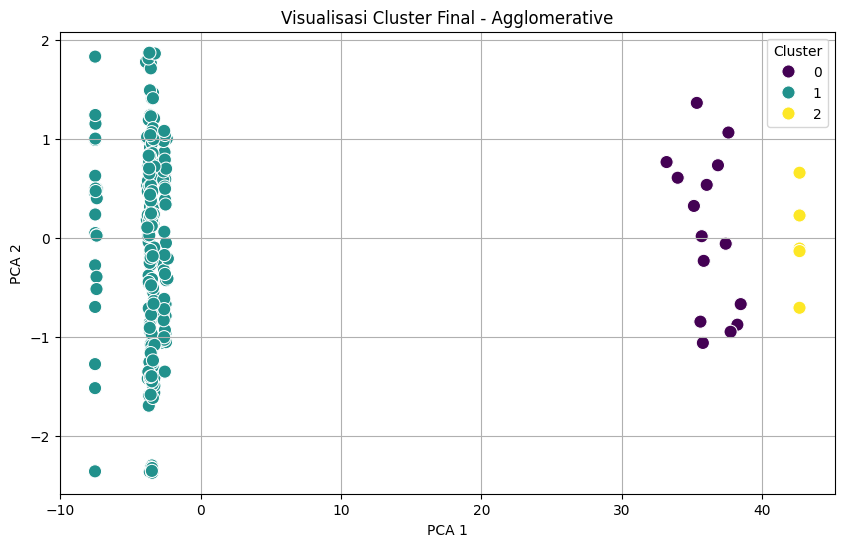

In [19]:
# ==============================================================================
# 17. VISUALISASI CLUSTER FINAL
# ==============================================================================
print("📍 VISUALISASI CLUSTER FINAL")
print("="*70)

# PCA 2D khusus visualisasi
X_vis = PCA(n_components=2, random_state=42).fit_transform(X_best_base)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_vis[:, 0],
    y=X_vis[:, 1],
    hue=df_country['Cluster'],
    palette='viridis',
    s=90
)

plt.title(f"Visualisasi Cluster Final - {best_algorithm}")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### 18. Distribusi Jumlah Negara per Cluster

Sel ini menampilkan distribusi jumlah negara yang termasuk dalam setiap cluster. Informasi ini disajikan dalam bentuk tabel dan diagram batang untuk memberikan pemahaman cepat tentang ukuran relatif masing-masing cluster.

📦 DISTRIBUSI CLUSTER


,count
Cluster,
0,15
1,200
2,5


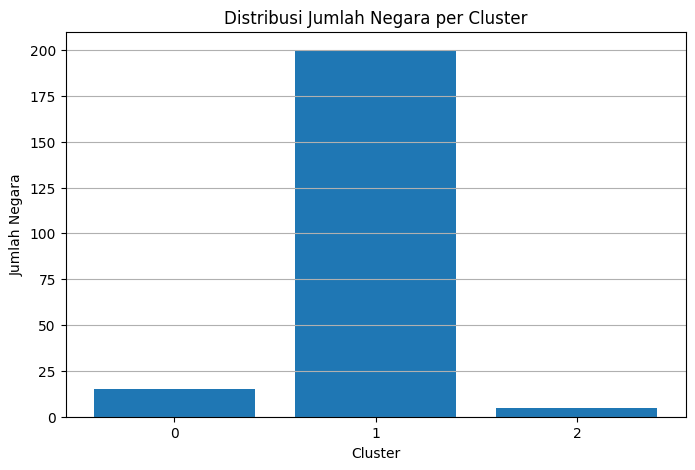

In [20]:
# ==============================================================================
# 18. DISTRIBUSI JUMLAH NEGARA PER CLUSTER
# ==============================================================================
print("📦 DISTRIBUSI CLUSTER")
print("="*70)

cluster_counts = df_country['Cluster'].value_counts().sort_index()

display(cluster_counts)

plt.figure(figsize=(8,5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title("Distribusi Jumlah Negara per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Negara")
plt.grid(axis='y')
plt.show()


### 19. Profil Cluster

Sel ini menganalisis karakteristik rata-rata dari fitur-fitur penting untuk setiap cluster. Hal ini membantu dalam menginterpretasikan makna dari setiap cluster dan membedakan profil satu cluster dengan yang lain. Hasilnya juga divisualisasikan dalam bentuk heatmap.

📊 PROFIL CLUSTER
Rata-rata fitur per cluster:


,Forest_Cover_Mean,Forest_Area_to_Land_Ratio,Carbon_per_Forest_Area,Forest_Cover_Change_Ratio
Cluster,,,,
0,35.5306,0.4015,1.280766e+04,8.3039
1,34.4537,0.3712,5.673501e+10,-0.1223
2,35.3116,0.3910,1.203185e+04,10.3647


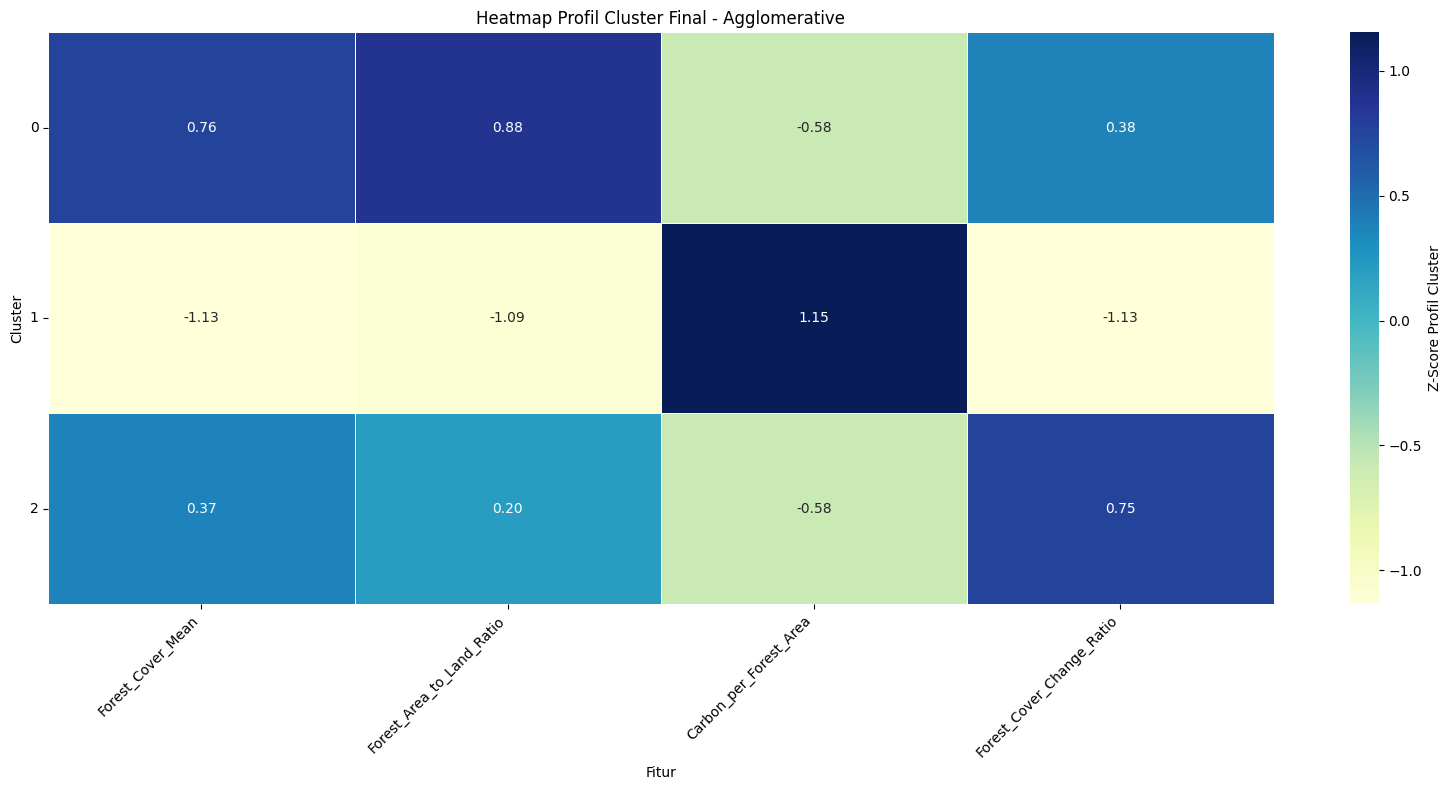

In [21]:
# ==============================================================================
# 19. PROFIL CLUSTER
# ==============================================================================
print("📊 PROFIL CLUSTER")
print("="*70)

profil = df_country.groupby('Cluster')[best_feature_set].mean().round(4)

print("Rata-rata fitur per cluster:")
display(profil)

# Standardisasi khusus visual biar heatmap terbaca
profil_scaled = (profil - profil.mean()) / profil.std()
profil_scaled = profil_scaled.replace([np.inf, -np.inf], np.nan).fillna(0)

plt.figure(figsize=(16, 8))
sns.heatmap(
    profil_scaled,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': 'Z-Score Profil Cluster'}
)

plt.title(f"Heatmap Profil Cluster Final - {best_algorithm}")
plt.xlabel("Fitur")
plt.ylabel("Cluster")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

20. DENDROGRAM

Sel ini digunakan untuk menampilkan dendrogram, yaitu representasi visual dari proses hierarchical clustering menggunakan metode Agglomerative. Fungsi linkage() digunakan untuk menghitung jarak antar data dan membentuk struktur penggabungan cluster dengan metode ward, yang meminimalkan variansi dalam cluster. Selanjutnya, fungsi dendrogram() digunakan untuk memvisualisasikan proses penggabungan tersebut dalam bentuk pohon hirarki. Sumbu vertikal menunjukkan jarak atau perbedaan antar cluster saat digabung, sedangkan sumbu horizontal merepresentasikan data atau kelompok data. Visualisasi ini membantu dalam memahami struktur cluster serta menentukan jumlah cluster yang optimal berdasarkan jarak pemisahan yang signifikan.


🌳 DENDROGRAM AGGLOMERATIVE


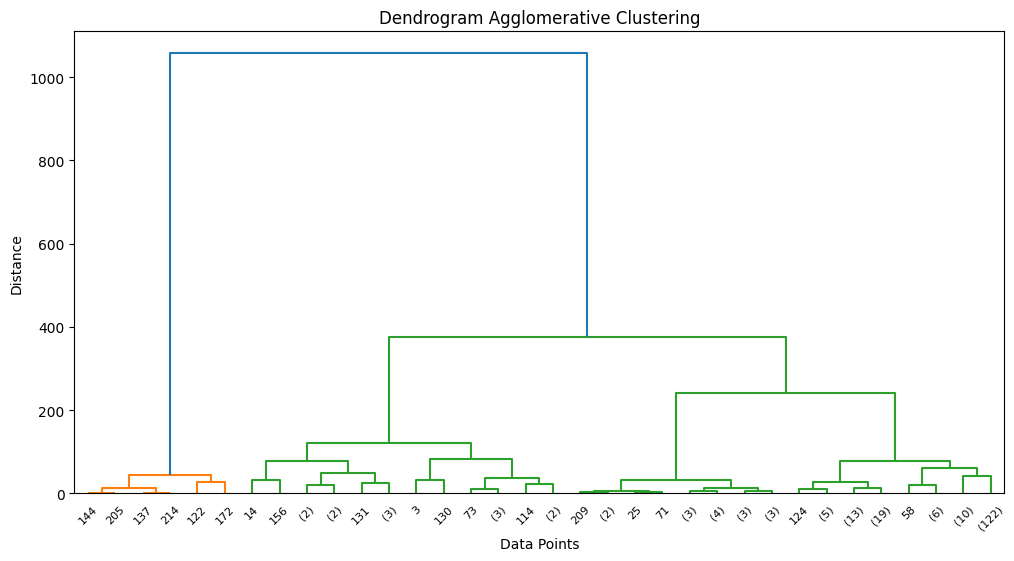

In [22]:
# ==============================================================================
# 20. DENDROGRAM (AGGLOMERATIVE)
# ==============================================================================
from scipy.cluster.hierarchy import dendrogram, linkage

print("🌳 DENDROGRAM AGGLOMERATIVE")
print("="*70)

linked = linkage(X_selected_df, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked,
           truncate_mode='level',
           p=5)
plt.title("Dendrogram Agglomerative Clustering")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

21. SILHOUETTE PLOT

Sel ini digunakan untuk menampilkan silhouette plot, yaitu visualisasi yang menggambarkan kualitas hasil clustering berdasarkan nilai silhouette setiap data. Fungsi silhouette_samples() menghitung nilai silhouette untuk masing-masing data berdasarkan jaraknya terhadap cluster sendiri dan cluster terdekat lainnya. Nilai tersebut kemudian diurutkan dan divisualisasikan per cluster menggunakan grafik horizontal. Setiap blok menunjukkan distribusi nilai dalam satu cluster, sehingga dapat dilihat apakah cluster tersebut kompak dan terpisah dengan baik. Garis vertikal menunjukkan nilai rata-rata silhouette dari seluruh data. Visualisasi ini membantu mengevaluasi apakah jumlah cluster yang dipilih sudah optimal dan apakah terdapat cluster yang kurang baik atau tumpang tindih.

📈 SILHOUETTE PLOT


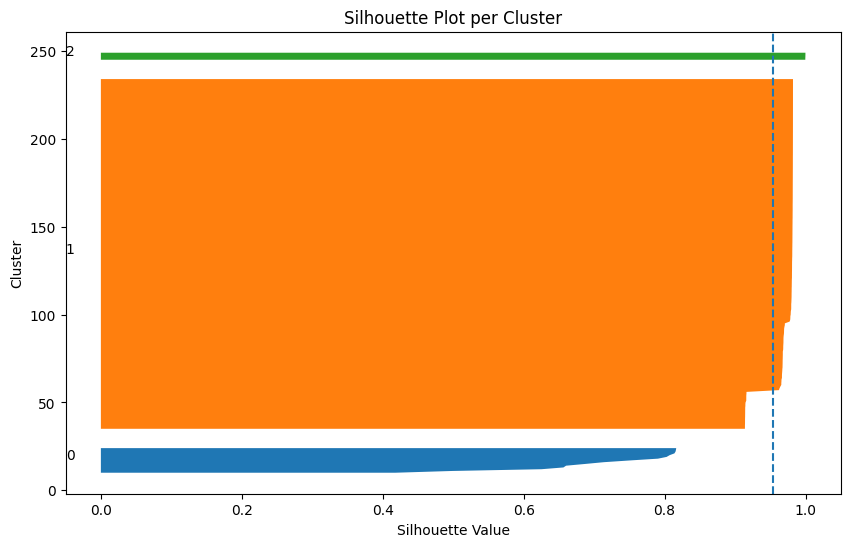

In [23]:
from sklearn.metrics import silhouette_samples

# ==============================================================================
# 21. SILHOUETTE PLOT FINAL MODEL
# ==============================================================================
print("📈 SILHOUETTE PLOT")
print("="*70)

sample_silhouette_values = silhouette_samples(X_final, final_labels)

y_lower = 10
plt.figure(figsize=(10,6))

for i in range(best_n_clusters):
    ith_cluster = sample_silhouette_values[final_labels == i]
    ith_cluster.sort()

    size_cluster = ith_cluster.shape[0]
    y_upper = y_lower + size_cluster

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster
    )

    plt.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
    y_lower = y_upper + 10

plt.title("Silhouette Plot per Cluster")
plt.xlabel("Silhouette Value")
plt.ylabel("Cluster")
plt.axvline(x=best_silhouette, linestyle="--")
plt.show()

22. ELBOW METHOD

Sel ini digunakan untuk menerapkan Elbow Method, yaitu teknik untuk menentukan jumlah cluster (k) yang optimal pada algoritma K-Means. Proses dilakukan dengan menjalankan K-Means untuk berbagai nilai k (dari 2 hingga 9), kemudian menghitung nilai inertia pada setiap k. Inertia merupakan ukuran seberapa dekat data dalam satu cluster (semakin kecil nilainya, semakin baik). Hasilnya divisualisasikan dalam bentuk grafik, di mana titik “siku” (elbow) menunjukkan perubahan penurunan inertia yang mulai melambat. Titik tersebut dianggap sebagai jumlah cluster optimal karena penambahan cluster setelahnya tidak memberikan peningkatan signifikan terhadap kualitas clustering.

📉 ELBOW METHOD


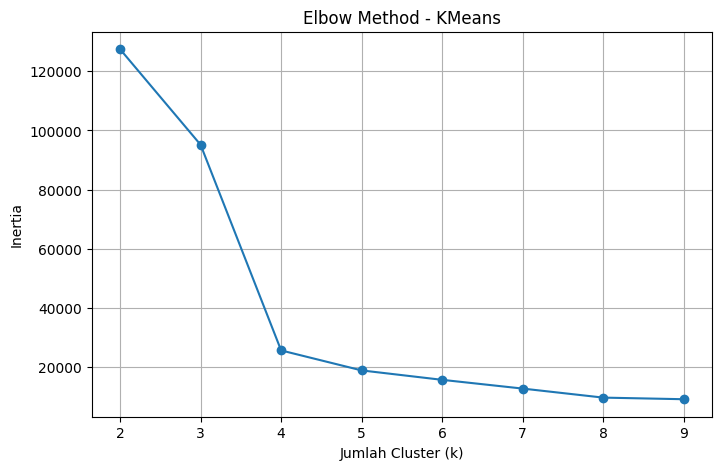

In [24]:
# ==============================================================================
# 22. ELBOW METHOD
# ==============================================================================
print("📉 ELBOW METHOD")
print("="*70)

inertia = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_selected_df)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method - KMeans")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

23. VISUALISASI CENTROID K-MEANS

Sel ini digunakan untuk menampilkan hasil clustering K-Means beserta posisi centroid sebagai pusat dari setiap cluster. Model K-Means dijalankan menggunakan jumlah cluster terbaik (best_n_clusters), kemudian menghasilkan label cluster untuk setiap data serta koordinat centroid. Untuk memudahkan visualisasi, data berdimensi tinggi direduksi menjadi dua dimensi menggunakan PCA. Data kemudian ditampilkan dalam bentuk scatter plot berdasarkan label cluster, sementara centroid divisualisasikan sebagai titik khusus berbentuk “X” dengan ukuran lebih besar. Visualisasi ini membantu memahami bagaimana data dikelompokkan serta menunjukkan posisi pusat masing-masing cluster sebagai representasi karakteristik kelompok data.

📍 CENTROID K-MEANS


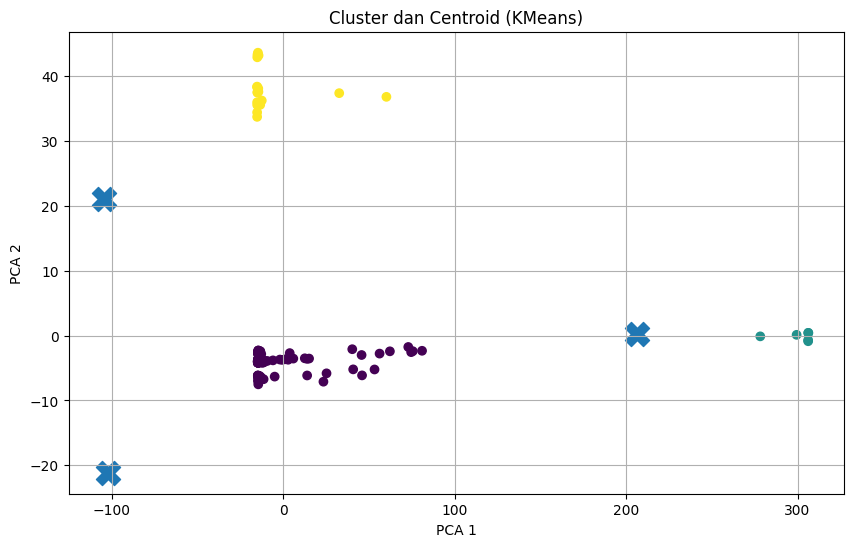

In [25]:
# ==============================================================================
# 23. VISUALISASI CENTROID K-MEANS
# ==============================================================================
print("📍 CENTROID K-MEANS")
print("="*70)

kmeans = KMeans(n_clusters=best_n_clusters, random_state=42)
labels_km = kmeans.fit_predict(X_selected_df)

centroids = kmeans.cluster_centers_

X_vis = PCA(n_components=2).fit_transform(X_selected_df)
centroids_vis = PCA(n_components=2).fit_transform(centroids)

plt.figure(figsize=(10,6))
plt.scatter(X_vis[:,0], X_vis[:,1], c=labels_km)
plt.scatter(centroids_vis[:,0], centroids_vis[:,1], s=300, marker='X')

plt.title("Cluster dan Centroid (KMeans)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

### 24. NEGARA DALAM SETIAP CLUSTER

Sel ini mencetak daftar negara yang termasuk dalam setiap cluster yang telah terbentuk. Ini memungkinkan identifikasi spesifik negara-negara yang memiliki pola deforestasi dan reboisasi serupa.

In [26]:
# ==============================================================================
# 24. NEGARA DALAM SETIAP CLUSTER
# ==============================================================================
print("🌍 DAFTAR NEGARA PER CLUSTER")
print("="*70)

for c in sorted(df_country['Cluster'].unique()):
    print(f"\n=== Cluster {c} ===")
    negara = df_country[df_country['Cluster'] == c]['Country'].tolist()
    print(negara[:50])


🌍 DAFTAR NEGARA PER CLUSTER

=== Cluster 0 ===
['Barbados', 'Costa Rica', 'Country_Gen_207', 'Country_Gen_213', 'Cuba', 'Jamaica', 'Mongolia', 'Mozambique', 'Namibia', 'Palau', 'Somalia', 'Tanzania', 'Togo', 'Trinidad and Tobago', 'Venezuela']

=== Cluster 1 ===
['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo (DRC)', 'Congo (Republic)', 'Country_Gen_194', 'Country_Gen_195', 'Country_Gen_196', 'Country_Gen_197', 'Country_Gen_198', 'Country_Gen_199', 'Country_Gen_200', 'Country_Gen_201', 'Country_Gen_202', 'Country_Gen_203', 'Country_Gen_204', 'Country_Gen_205', 'Country_Gen_206']

=== Cluster 2

### 25. ANALISIS DEFORESTASI DAN REBOISASI

Sel ini memberikan analisis tambahan mengenai negara-negara dengan rata-rata deforestasi dan reboisasi tertinggi, serta `Net_Forest_Change` (perubahan hutan bersih) terbaik dan terburuk. Ini menyoroti negara-negara dengan tren ekstrem dalam pengelolaan hutan.

In [27]:
# ==============================================================================
# 25. ANALISIS DEFORESTASI DAN REBOISASI
# ==============================================================================
print("🌲 ANALISIS DEFORESTASI & REBOISASI")
print("="*70)

print("\n🔻 10 Negara dengan rata-rata deforestasi tertinggi:")
display(
    df_country[['Country', 'Deforestation_Mean']]
    .sort_values(by='Deforestation_Mean', ascending=False)
    .head(10)
)

print("\n🌱 10 Negara dengan rata-rata afforestasi tertinggi:")
display(
    df_country[['Country', 'Afforestation_Mean']]
    .sort_values(by='Afforestation_Mean', ascending=False)
    .head(10)
)

print("\n📉 10 Negara dengan Net Forest Change terburuk:")
display(
    df_country[['Country', 'Net_Forest_Change_Mean']]
    .sort_values(by='Net_Forest_Change_Mean', ascending=True)
    .head(10)
)

print("\n📈 10 Negara dengan Net Forest Change terbaik:")
display(
    df_country[['Country', 'Net_Forest_Change_Mean']]
    .sort_values(by='Net_Forest_Change_Mean', ascending=False)
    .head(10)
)


🌲 ANALISIS DEFORESTASI & REBOISASI

🔻 10 Negara dengan rata-rata deforestasi tertinggi:


,Country,Deforestation_Mean
86,Gabon,106.961538
215,Venezuela,99.423077
52,Country_Gen_205,98.423077
6,Argentina,96.076923
211,Uruguay,91.923077
143,Namibia,91.076923
111,Kazakhstan,90.923077
175,Senegal,90.115385
41,Country_Gen_194,89.769231
159,Paraguay,89.384615



🌱 10 Negara dengan rata-rata afforestasi tertinggi:


,Country,Afforestation_Mean
187,Spain,76.076923
214,Vatican City,72.615385
85,France,72.461538
80,Estonia,71.038462
162,Poland,70.692308
130,Malta,70.192308
16,Belgium,69.076923
25,Bulgaria,68.884615
1,Albania,68.384615
181,Slovenia,68.384615



📉 10 Negara dengan Net Forest Change terburuk:


,Country,Net_Forest_Change_Mean
52,Country_Gen_205,-61.730769
86,Gabon,-60.692308
215,Venezuela,-52.769231
143,Namibia,-51.500000
111,Kazakhstan,-50.153846
6,Argentina,-48.038462
114,Kuwait,-46.730769
190,Suriname,-46.038462
57,Country_Gen_210,-45.923077
47,Country_Gen_200,-45.346154



📈 10 Negara dengan Net Forest Change terbaik:


,Country,Net_Forest_Change_Mean
187,Spain,62.307692
85,France,58.500000
162,Poland,55.884615
152,North Macedonia,55.653846
130,Malta,53.692308
210,United Kingdom,53.500000
181,Slovenia,53.461538
98,Hungary,52.692308
16,Belgium,51.653846
80,Estonia,50.346154


### 26. SIMPAN HASIL

Sel ini menyimpan hasil-hasil penting dari proses clustering, termasuk DataFrame `df_country` dengan label cluster, hasil evaluasi algoritma, serta objek `scaler` dan `imputer` yang digunakan dalam preprocessing. Ini penting untuk dokumentasi dan penggunaan di masa mendatang.

In [28]:
# ==============================================================================
# 26. SIMPAN HASIL
# ==============================================================================
print("💾 MENYIMPAN HASIL")
print("="*70)

df_country.to_csv('hasil_clustering_negara_final.csv', index=False)
df_eval.to_csv('hasil_evaluasi_3_algoritma.csv', index=False)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)

print("✅ File berhasil disimpan:")
print("- hasil_clustering_negara_final.csv")
print("- hasil_evaluasi_3_algoritma.csv")
print("- scaler.pkl")
print("- imputer.pkl")



💾 MENYIMPAN HASIL
✅ File berhasil disimpan:
- hasil_clustering_negara_final.csv
- hasil_evaluasi_3_algoritma.csv
- scaler.pkl
- imputer.pkl


27. DOWNLOAD FILE

Mendownload file hasil clustering negara final dan hasil evaluasi 3 algoritma

In [29]:
# ==============================================================================
# 27. DOWNLOAD FILE
# ==============================================================================

files.download('hasil_clustering_negara_final.csv')
files.download('hasil_evaluasi_3_algoritma.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 28. MEMBUAT DAN DOWNLOAD app.py (DASHBOARD STREAMLIT FINAL)

Sel ini membuat file Python (`app.py`) yang berisi kode lengkap untuk dashboard interaktif menggunakan Streamlit. Dashboard ini akan memvisualisasikan hasil clustering dan analisis secara user-friendly.

In [36]:
# ==============================================================================
# 28. MEMBUAT DAN DOWNLOAD app.py (DASHBOARD STREAMLIT FINAL)
# ==============================================================================

STREAMLIT_APP_CODE = """import streamlit as st
import pandas as pd
import plotly.express as px
import numpy as np

# ------------------------------------------------------------------------------
# KONFIGURASI HALAMAN
# ------------------------------------------------------------------------------
st.set_page_config(
    page_title="Clustering Negara - Deforestasi & Reboisasi",
    layout="wide"
)

# ------------------------------------------------------------------------------
# CSS STYLE
# ------------------------------------------------------------------------------
css_content = \"\"\"
<style>
body {
    background-color: #fff8fc;
}
.main {
    background: linear-gradient(135deg, #ffe4f2, #e6f7ff);
}
h1, h2, h3 {
    color: #d63384;
    font-family: 'Trebuchet MS', sans-serif;
}
[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #ffd6ec, #dff6ff);
}
div.stButton > button {
    background-color: #ff99cc;
    color: white;
    border-radius: 12px;
    border: none;
}
[data-testid="metric-container"] {
    background-color: rgba(255,255,255,0.6);
    border-radius: 14px;
    padding: 12px;
    box-shadow: 0px 2px 8px rgba(0,0,0,0.08);
}
.metric-card {
    background: white;
    border-radius: 12px;
    padding: 20px;
    text-align: center;
    box-shadow: 0 2px 8px rgba(214,51,132,0.08);
}
.metric-value {
    font-size: 2.5rem;
    font-weight: bold;
    color: #d63384;
}
.metric-label {
    font-size: 0.9rem;
    color: #888;
}
</style>
\"\"\"
st.markdown(css_content, unsafe_allow_html=True)

# ------------------------------------------------------------------------------
# JUDUL
# ------------------------------------------------------------------------------
st.title("🌍 Clustering Negara Berdasarkan Pola Deforestasi dan Reboisasi Global untuk Mendukung Kebijakan Lingkungan menggunakan Agglomerative")

# ------------------------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------------------------
df = pd.read_csv('hasil_clustering_negara_final.csv')
df_eval = pd.read_csv('hasil_evaluasi_3_algoritma.csv')

# ------------------------------------------------------------------------------
# FITUR
# ------------------------------------------------------------------------------
model_features = [
    'Forest_Cover_Mean',
    'Forest_Area_to_Land_Ratio',
    'Carbon_per_Forest_Area',
    'Forest_Cover_Change_Ratio'
]

dashboard_features = [
    'Forest_Cover_Mean',
    'Net_Forest_Change_Mean',
    'Forest_Area_to_Land_Ratio',
    'Carbon_per_Forest_Area',
    'Deforestation_Intensity',
    'Afforestation_Intensity',
    'Forest_Cover_Change_Ratio',
    'Forest_Stability_Index'
]
dashboard_features = [f for f in dashboard_features if f in df.columns]

# ------------------------------------------------------------------------------
# INFO MODEL
# ------------------------------------------------------------------------------
best_algorithm = "Agglomerative"
best_param = "k=3, linkage=complete"
best_silhouette = 0.9543
best_quality = 95.43
best_n_clusters = 3

# ------------------------------------------------------------------------------
# SIDEBAR
# ------------------------------------------------------------------------------
st.sidebar.header("🎀 Informasi Model")
st.sidebar.success(f"Algoritma Terbaik: {best_algorithm}")
st.sidebar.info(f"Parameter: {best_param}")
st.sidebar.info(f"Jumlah Cluster: {best_n_clusters}")
st.sidebar.info(f"Silhouette Score: {best_silhouette:.4f}")
st.sidebar.info(f"Kualitas Cluster: {best_quality:.2f}%")

st.sidebar.markdown("---")
st.sidebar.subheader("📌 Fitur Model Terbaik")
for i, feat in enumerate(model_features, 1):
    st.sidebar.markdown(f"**{i}.** {feat}")

st.sidebar.markdown("---")
cluster_options = sorted(df['Cluster'].dropna().unique().tolist())
selected_clusters = st.sidebar.multiselect(
    "Pilih Cluster",
    cluster_options,
    default=cluster_options
)

df_filtered = df[df['Cluster'].isin(selected_clusters)]

if df_filtered.empty:
    st.warning("⚠️ Tidak ada data untuk cluster yang dipilih.")
    st.stop()

# ------------------------------------------------------------------------------
# RINGKASAN DATA
# ------------------------------------------------------------------------------
st.markdown("## 📌 Ringkasan Data")

col1, col2, col3 = st.columns(3)
with col1:
    st.markdown(\"\"\"
    <div class="metric-card">
        <div class="metric-label">Jumlah Negara</div>
        <div class="metric-value">{}</div>
    </div>
    \"\"\".format(len(df_filtered)), unsafe_allow_html=True)
with col2:
    st.markdown(\"\"\"
    <div class="metric-card">
        <div class="metric-label">Jumlah Cluster</div>
        <div class="metric-value">{}</div>
    </div>
    \"\"\".format(df_filtered['Cluster'].nunique()), unsafe_allow_html=True)
with col3:
    st.markdown(\"\"\"
    <div class="metric-card">
        <div class="metric-label">Kualitas Cluster</div>
        <div class="metric-value">{:.2f}%</div>
    </div>
    \"\"\".format(best_quality), unsafe_allow_html=True)

st.markdown("<br>", unsafe_allow_html=True)

# ------------------------------------------------------------------------------
# PERBANDINGAN 3 ALGORITMA
# ------------------------------------------------------------------------------
st.markdown("## 🏆 Perbandingan 3 Algoritma")

best_per_algo = (
    df_eval
    .sort_values(
        by=['Algoritma', 'Silhouette', 'Davies_Bouldin', 'Calinski_Harabasz'],
        ascending=[True, False, True, False]
    )
    .groupby('Algoritma', as_index=False)
    .first()
)

st.dataframe(best_per_algo, use_container_width=True)

color_map = {'Agglomerative': '#1f77b4', 'DBSCAN': '#aec7e8', 'K-Means': '#d62728'}
fig_sil = px.bar(
    best_per_algo,
    x='Algoritma',
    y='Silhouette',
    color='Algoritma',
    color_discrete_map=color_map,
    text='Silhouette',
    title="Silhouette Score Terbaik per Algoritma"
)
fig_sil.update_traces(texttemplate='%{text:.4f}', textposition='outside')
fig_sil.update_layout(yaxis_range=[0, 1.05], showlegend=True)
st.plotly_chart(fig_sil, use_container_width=True)

# ------------------------------------------------------------------------------
# DISTRIBUSI CLUSTER
# ------------------------------------------------------------------------------
st.markdown("## 📊 Distribusi Cluster")

cluster_count = df_filtered['Cluster'].value_counts().sort_index().reset_index()
cluster_count.columns = ['Cluster', 'Jumlah']

fig_count = px.bar(
    cluster_count,
    x='Cluster',
    y='Jumlah',
    color='Cluster',
    text='Jumlah',
    title="Distribusi Jumlah Negara per Cluster"
)
fig_count.update_traces(textposition='outside')
st.plotly_chart(fig_count, use_container_width=True)

# ------------------------------------------------------------------------------
# PETA PERSEBARAN NEGARA
# ------------------------------------------------------------------------------
st.markdown("## 🗺️ Peta Persebaran Negara")

fig_map = px.choropleth(
    df_filtered,
    locations="Country",
    locationmode='country names',
    color="Cluster",
    hover_name="Country",
    color_continuous_scale='Blues',
    title="Peta Persebaran Cluster Negara"
)
st.plotly_chart(fig_map, use_container_width=True)

# ------------------------------------------------------------------------------
# PROFIL RATA-RATA FITUR PER CLUSTER
# ------------------------------------------------------------------------------
st.markdown("## 📈 Profil Rata-rata Fitur per Cluster")

numeric_cols = df_filtered.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'Cluster']

profil = df_filtered.groupby('Cluster')[numeric_cols].mean().reset_index()
st.dataframe(profil, use_container_width=True)

# ------------------------------------------------------------------------------
# ANALISIS FITUR PER CLUSTER
# ------------------------------------------------------------------------------
st.markdown("## 📉 Analisis Fitur per Cluster")

selected_feature = st.selectbox(
    "Pilih fitur yang ingin dianalisis",
    dashboard_features
)

fig_box = px.box(
    df_filtered,
    x='Cluster',
    y=selected_feature,
    color='Cluster',
    points='all',
    title=f"Distribusi {selected_feature} per Cluster"
)
st.plotly_chart(fig_box, use_container_width=True)

# ------------------------------------------------------------------------------
# NEGARA DEFORESTASI TERTINGGI
# ------------------------------------------------------------------------------
st.markdown("## 🌲 Negara dengan Deforestasi Tertinggi")

if 'Deforestation_Mean' in df_filtered.columns:
    top_def = df_filtered.sort_values(by='Deforestation_Mean', ascending=False).head(10)

    fig_def = px.bar(
        top_def,
        x='Deforestation_Mean',
        y='Country',
        orientation='h',
        color='Cluster',
        text='Deforestation_Mean',
        title="10 Negara dengan Deforestasi Tertinggi"
    )
    fig_def.update_traces(texttemplate='%{text:.2f}', textposition='outside')
    fig_def.update_layout(yaxis={'categoryorder': 'total ascending'})
    st.plotly_chart(fig_def, use_container_width=True)
    st.dataframe(
        top_def[['Country', 'Cluster', 'Deforestation_Mean']],
        use_container_width=True
    )

# ------------------------------------------------------------------------------
# NEGARA REBOISASI TERTINGGI
# ------------------------------------------------------------------------------
st.markdown("## 🌱 Negara dengan Reboisasi Tertinggi")

if 'Afforestation_Mean' in df_filtered.columns:
    top_aff = df_filtered.sort_values(by='Afforestation_Mean', ascending=False).head(10)

    fig_aff = px.bar(
        top_aff,
        x='Afforestation_Mean',
        y='Country',
        orientation='h',
        color='Cluster',
        text='Afforestation_Mean',
        title="10 Negara dengan Reboisasi Tertinggi"
    )
    fig_aff.update_traces(texttemplate='%{text:.2f}', textposition='outside')
    fig_aff.update_layout(yaxis={'categoryorder': 'total ascending'})
    st.plotly_chart(fig_aff, use_container_width=True)
    st.dataframe(
        top_aff[['Country', 'Cluster', 'Afforestation_Mean']],
        use_container_width=True
    )

# ------------------------------------------------------------------------------
# DATA HASIL CLUSTERING
# ------------------------------------------------------------------------------
st.markdown("## 🧾 Data Hasil Clustering")

search_country = st.text_input("🔍 Cari Negara", "")
if search_country:
    df_show = df_filtered[df_filtered['Country'].str.contains(search_country, case=False, na=False)]
else:
    df_show = df_filtered

st.dataframe(df_show, use_container_width=True)
"""

# ------------------------------------------------------------------------------
# SIMPAN DAN DOWNLOAD app.py
# ------------------------------------------------------------------------------
with open("app.py", "w", encoding="utf-8") as f:
    f.write(STREAMLIT_APP_CODE)

print("✅ app.py berhasil dibuat!")

# Download ke laptop
from google.colab import files
files.download("app.py")



✅ app.py berhasil dibuat!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

29. MENDOWNLOAD LIBRARY STREAMLIT

Sel ini digunakan untuk menginstal library Streamlit secara terprogram menggunakan modul subprocess. Fungsi install_package() dibuat untuk menjalankan perintah pip install di dalam environment Python secara langsung. Parameter -q digunakan agar proses instalasi berjalan dalam mode senyap (quiet) tanpa menampilkan output yang terlalu panjang. Jika instalasi berhasil, akan muncul pesan konfirmasi bertanda ✅, sedangkan jika gagal akan muncul pesan error bertanda ❌. Fungsi ini kemudian dipanggil dengan argumen "streamlit" untuk menginstal library Streamlit yang dibutuhkan dalam pembuatan dashboard interaktif.

In [32]:
# ==============================================================================
# 29. MENDOWNLOAD LIBRARY STREAMLIT
# ==============================================================================

import subprocess

def install_package(package):
    try:
        subprocess.check_call(["pip", "install", "-q", package])
        print(f"✅ {package} installed successfully.")
    except subprocess.CalledProcessError:
        print(f"❌ Failed to install {package}.")

install_package("streamlit")


✅ streamlit installed successfully.
